In [2]:
#!/usr/bin/env python
"""
Compute the Jaccard overlap of the top‑k (default 5 %) absolute‑magnitude weights
between *any* pair drawn from three GSM8K weight‑only WANDe disentanglement runs:
    • CoT‑0‑shot (cot)
    • Direct (direct)
    • CoT‑0‑shot‑gold‑reason (golden)

Fixed version that handles both PyTorch .pt files and pickle .pkl files.
"""

import os
import pickle
import re
import itertools
import time
from collections import defaultdict
from tqdm import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------------------------------------------------
# Configuration ────────────────────────────────────────────────────────────────
# -----------------------------------------------------------------------------

DATASETS = {
    "cot": {
        "dir": "../out/llama2-7b-chat-hf/unstructured/wanda_weightonly/GSM8K_cot0shot_120/wanda_score/GSM8K_cot0shot_120_weight_only_disentangle",
        "tag": "GSM8K_cot0shot_120",
    },
    "direct": {
        "dir": "../out/llama2-7b-chat-hf/unstructured/wanda_weightonly/GSM8K_direct_120/wanda_score/GSM8K_direct_120_weight_only_disentangle",
        "tag": "GSM8K_direct_120",
    },
    "golden": {
        "dir": "../out/llama2-7b-chat-hf/unstructured/wanda_weightonly/GSM8K_cot0shot_goldreason/wanda_score/GSM8K_cot0shot_goldreason_weight_only_disentangle",
        "tag": "GSM8K_cot0shot_goldreason",
    },
    "cot4shot": {
        "dir": "../out/llama2-7b-chat-hf/unstructured/wanda_weightonly/GSM8K_cot4shot_120/wanda_score/GSM8K_cot4shot_120_weight_only_disentangle",
        "tag": "GSM8K_cot4shot_120",
    },
}

# Map human‑readable category names (left) to the substrings contained in the
# Wanda pickle filenames (right).
CATEGORIES = {
    "self_attn.q": "q_proj",
    "self_attn.k": "k_proj",
    "self_attn.v": "v_proj",
    "self_attn.o": "o_proj",
    "mlp.down": "down_proj",
    "mlp.gate": "gate_proj",
    "mlp.up": "up_proj",
}

TOPK_RATIO = 0.05  # top‑5 % mask

# -----------------------------------------------------------------------------
# Helper utilities ─────────────────────────────────────────────────────────────
# -----------------------------------------------------------------------------

def load_tensor(path):
    """Load a Wanda .pkl file and return the underlying NumPy weight array.
    Only handles pickle .pkl files, skips .pt files."""
    # Only process .pkl files
    if not path.endswith('.pkl'):
        raise ValueError(f"Only .pkl files are supported, got: {path}")
    
    with open(path, "rb") as fh:
        obj = pickle.load(fh)
    
    if isinstance(obj, dict):
        # Wanda score dumps sometimes wrap the tensor under a 'weight' key
        obj = obj.get("weight", next(iter(obj.values())))
    return obj.detach().cpu().numpy()


def topk_mask(tensor: np.ndarray, ratio: float = TOPK_RATIO) -> np.ndarray:
    """Return a bool mask with 1s at the top‑|ratio| absolute entries."""
    flat = np.abs(tensor).ravel()
    k = max(1, int(flat.size * ratio))
    thresh = np.partition(flat, -k)[-k]
    return (np.abs(tensor) >= thresh)


def jaccard(m1: np.ndarray, m2: np.ndarray) -> float:
    inter = np.logical_and(m1, m2).sum()
    union = np.logical_or(m1, m2).sum()
    return float(inter) / union if union else 0.0


# -----------------------------------------------------------------------------
# Core computation ─────────────────────────────────────────────────────────────
# -----------------------------------------------------------------------------

def collect_pairwise(pair: tuple[str, str]):
    """Compute Jaccard matrix for one dataset *pair* (e.g. ('cot','direct'))."""
    name_a, name_b = pair
    
    dir_a, tag_a = DATASETS[name_a].values()
    dir_b, tag_b = DATASETS[name_b].values()

    out = defaultdict(dict)  # out[layer][category] = jaccard value

    # Get list of .pkl files to process
    pkl_files = [fname for fname in os.listdir(dir_a) 
                 if tag_a in fname and fname.endswith('.pkl')]
    
    processed_count = 0
    skipped_count = 0
    
    for fname in tqdm(pkl_files, desc=f"Processing {name_a}_vs_{name_b}", leave=False):
        fname_b = fname.replace(tag_a, tag_b)
        path_a, path_b = os.path.join(dir_a, fname), os.path.join(dir_b, fname_b)
        if not os.path.exists(path_b):
            skipped_count += 1
            continue  # skip mismatching layers / categories

        try:
            t_a = load_tensor(path_a)
            t_b = load_tensor(path_b)
        except Exception as exc:  # corrupt file, skip with a warning
            print(f"⚠️  Skipping {fname} → {fname_b}: {exc}")
            skipped_count += 1
            continue
        
        m_a, m_b = topk_mask(t_a), topk_mask(t_b)
        jac = jaccard(m_a, m_b)

        # Determine layer and category from filename
        layer_match = re.search(r"layer_(\d+)", fname)
        if not layer_match:
            skipped_count += 1
            continue
        layer = int(layer_match.group(1))

        for cat_name, cat_key in CATEGORIES.items():
            if cat_key in fname:
                out[layer][cat_name] = jac
                processed_count += 1
                break

    print(f"  Processed: {processed_count} files, Skipped: {skipped_count} files")
    return out


# Aggregate across all three choose‑two pairs
print("Starting pairwise Jaccard computation...")
start_time = time.time()

pair_results = {}
pairs = list(itertools.combinations(DATASETS.keys(), 2))
for pair in tqdm(pairs, desc="Processing pairs"):
    pair_name = f"{pair[0]}_vs_{pair[1]}"
    print(f"\nProcessing pair: {pair_name}")
    pair_start_time = time.time()
    pair_results[pair_name] = collect_pairwise(pair)
    pair_end_time = time.time()
    print(f"Completed {pair_name} in {pair_end_time - pair_start_time:.2f} seconds")

total_time = time.time() - start_time
print(f"\nTotal computation time: {total_time:.2f} seconds")


Starting pairwise Jaccard computation...


Processing pairs:   0%|          | 0/6 [00:00<?, ?it/s]


Processing pair: cot_vs_direct


Processing pairs:  17%|█▋        | 1/6 [07:23<36:58, 443.61s/it]

  Processed: 224 files, Skipped: 0 files
Completed cot_vs_direct in 443.61 seconds

Processing pair: cot_vs_golden


...

  Processed: 224 files, Skipped: 0 files
Completed direct_vs_golden in 406.81 seconds

Processing pair: direct_vs_cot4shot


Processing pairs:  83%|████████▎ | 5/6 [32:35<06:27, 387.89s/it]

  Processed: 224 files, Skipped: 0 files
Completed direct_vs_cot4shot in 393.55 seconds

Processing pair: golden_vs_cot4shot


Processing pairs: 100%|██████████| 6/6 [41:24<00:00, 414.07s/it]

  Processed: 224 files, Skipped: 0 files
Completed golden_vs_cot4shot in 528.75 seconds

Total computation time: 2484.41 seconds


Creating DataFrame...
DataFrame created in 0.02 seconds
DataFrame shape: (1344, 4)
Creating visualization...
Plot created in 4.90 seconds


<Figure size 1800x500 with 0 Axes>

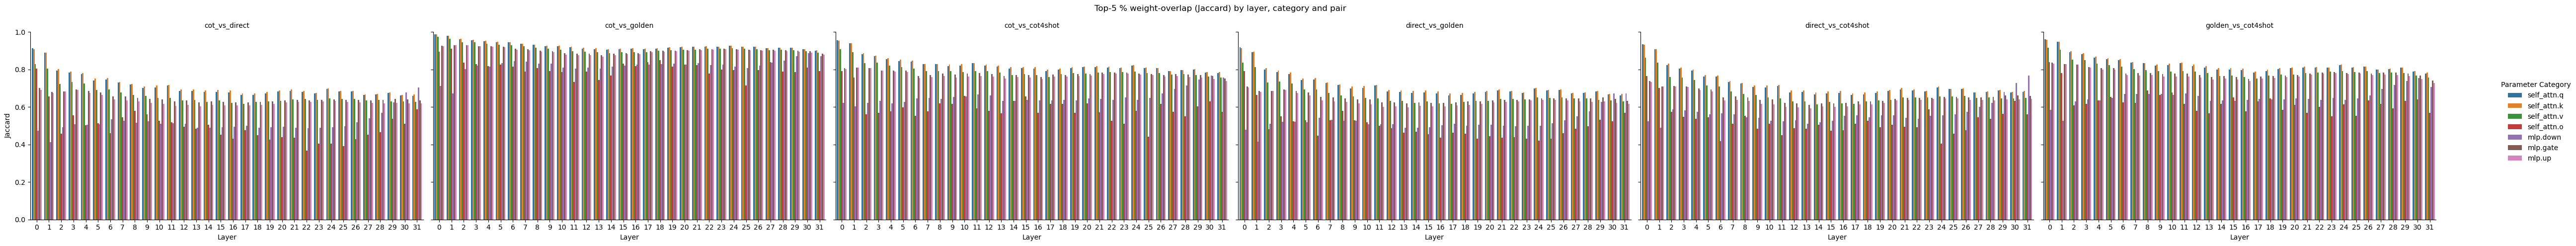


==== Mean Jaccard per category (averaged over layers) ====
              Pair    Category  Jaccard
   cot_vs_cot4shot    mlp.down 0.655149
   cot_vs_cot4shot    mlp.gate 0.777935
   cot_vs_cot4shot      mlp.up 0.768616
   cot_vs_cot4shot self_attn.k 0.828851
   cot_vs_cot4shot self_attn.o 0.596117
   cot_vs_cot4shot self_attn.q 0.824889
   cot_vs_cot4shot self_attn.v 0.793325
     cot_vs_direct    mlp.down 0.517671
     cot_vs_direct    mlp.gate 0.646100
     cot_vs_direct      mlp.up 0.631449
     cot_vs_direct self_attn.k 0.716029
     cot_vs_direct self_attn.o 0.494541
     cot_vs_direct self_attn.q 0.710439
     cot_vs_direct self_attn.v 0.661828
     cot_vs_golden    mlp.down 0.820437
     cot_vs_golden    mlp.gate 0.903126
     cot_vs_golden      mlp.up 0.898425
     cot_vs_golden self_attn.k 0.928009
     cot_vs_golden self_attn.o 0.807619
     cot_vs_golden self_attn.q 0.926322
     cot_vs_golden self_attn.v 0.912547
direct_vs_cot4shot    mlp.down 0.567469
direct_vs_cot4shot  

In [3]:

# -----------------------------------------------------------------------------
# Tidy DataFrame for plotting / stats ─────────────────────────────────────────
# -----------------------------------------------------------------------------
print("Creating DataFrame...")
df_start_time = time.time()

rows = []
for pair_name, matrix in pair_results.items():
    for layer, cats in matrix.items():
        for cat in CATEGORIES.keys():
            rows.append({
                "Pair": pair_name,
                "Layer": layer,
                "Category": cat,
                "Jaccard": cats.get(cat, np.nan),
            })

df = pd.DataFrame(rows)
df_time = time.time() - df_start_time
print(f"DataFrame created in {df_time:.2f} seconds")
print(f"DataFrame shape: {df.shape}")

# -----------------------------------------------------------------------------
# Visualisation ────────────────────────────────────────────────────────────────
# -----------------------------------------------------------------------------
print("Creating visualization...")
plot_start_time = time.time()

plt.figure(figsize=(18, 5))
cat_plot = sns.catplot(
    data=df,
    x="Layer",
    y="Jaccard",
    hue="Category",
    col="Pair",
    kind="bar",
    palette="tab10",
    height=5,
    aspect=1.6,
)
cat_plot.set_titles("{col_name}")
cat_plot.set(ylim=(0, 1))
cat_plot.fig.subplots_adjust(top=0.85)
cat_plot.fig.suptitle("Top‑5 % weight‑overlap (Jaccard) by layer, category and pair")
legend = cat_plot._legend
legend.set_title("Parameter Category")
legend.set_bbox_to_anchor((1.02, 0.5))  # move legend outside the plot
legend.set_loc("center left")
plt.tight_layout()

plot_time = time.time() - plot_start_time
print(f"Plot created in {plot_time:.2f} seconds")
plt.show()

# -----------------------------------------------------------------------------
# Statistics ─────────────────────────────────────────────────────────────────--
# -----------------------------------------------------------------------------
print("\n==== Mean Jaccard per category (averaged over layers) ====")
mean_table = (
    df.groupby(["Pair", "Category"], as_index=False)["Jaccard"]
    .mean()
    .sort_values(["Pair", "Category"])
)
print(mean_table.to_string(index=False))

# total average
total_mean = df["Jaccard"].mean()
print(f"\n==== Overall mean Jaccard index: {total_mean:.4f} ====")

# -----------------------------------------------------------------------------
# Timing Summary ───────────────────────────────────────────────────────────────
# -----------------------------------------------------------------------------
print(f"\n==== TIMING SUMMARY ====")
print(f"Total computation time: {total_time:.2f} seconds")
print(f"DataFrame creation: {df_time:.2f} seconds")
print(f"Plot creation: {plot_time:.2f} seconds")
print(f"Total execution time: {time.time() - start_time:.2f} seconds")
print(f"Number of pairs processed: {len(pairs)}")
print(f"DataFrame shape: {df.shape}")


Creating DataFrame...
DataFrame created in 0.00 seconds
DataFrame shape: (1344, 4)
Saved CSV: out/jaccard_analysis.csv
Creating visualization...
Saved PNG: figures/jaccard_analysis_20250811_160904.png
Saved PDF: figures/jaccard_analysis_20250811_160904.pdf
Saved SVG: figures/jaccard_analysis_20250811_160904.svg
Plot created and saved in 10.74 seconds


<Figure size 1800x500 with 0 Axes>

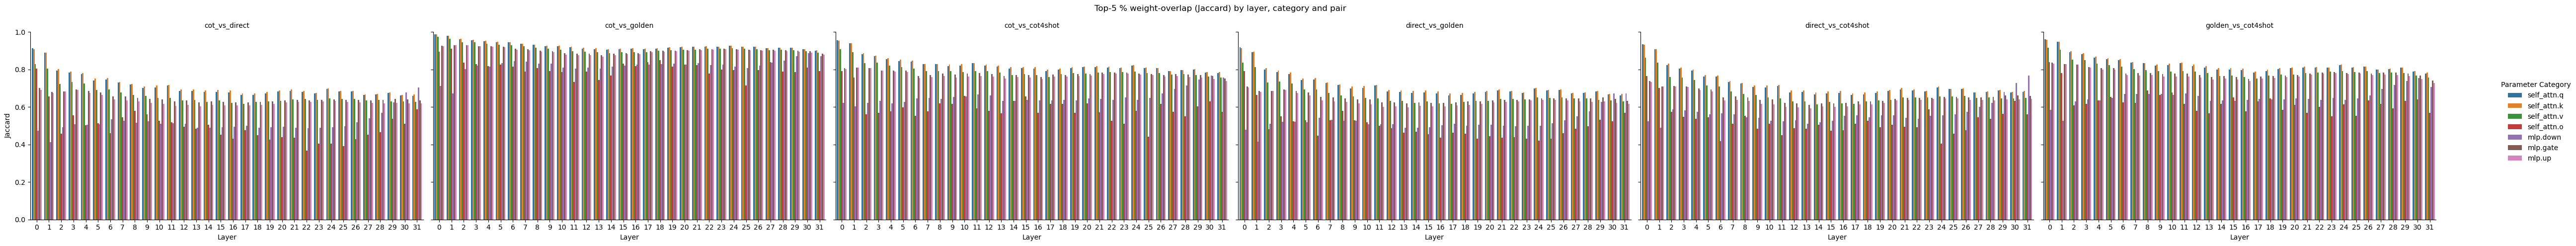

Creating summary plot...
Saved Summary PNG: figures/jaccard_analysis_20250811_160904_summary.png
Saved Summary PDF: figures/jaccard_analysis_20250811_160904_summary.pdf
Summary plot created and saved in 0.89 seconds


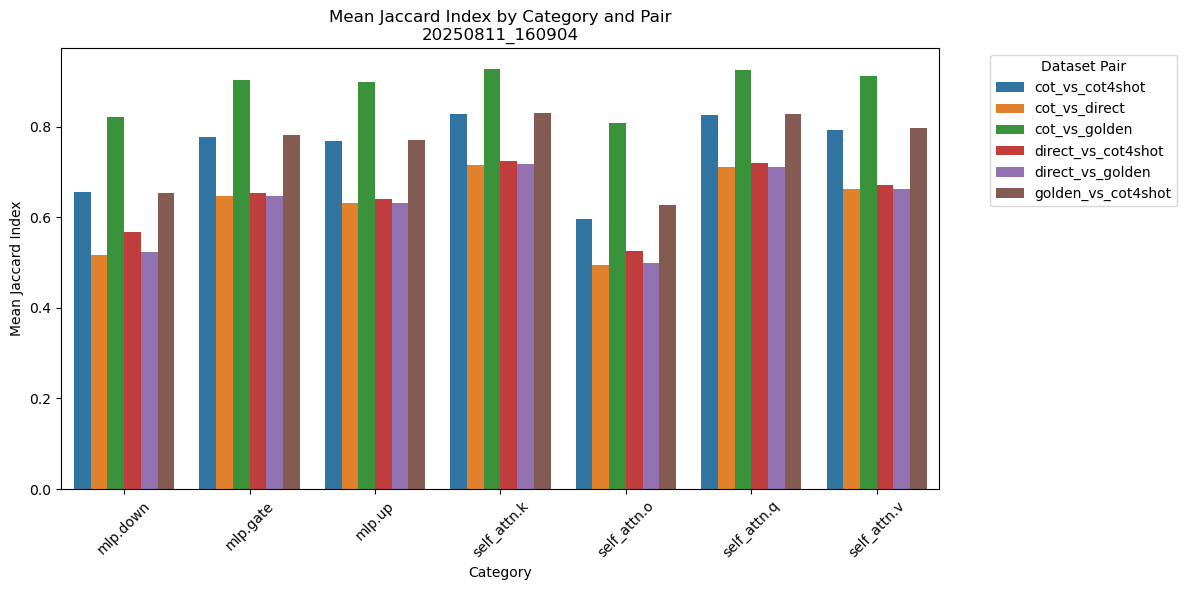


==== Mean Jaccard per category (averaged over layers) ====
              Pair    Category  Jaccard
   cot_vs_cot4shot    mlp.down 0.655149
   cot_vs_cot4shot    mlp.gate 0.777935
   cot_vs_cot4shot      mlp.up 0.768616
   cot_vs_cot4shot self_attn.k 0.828851
   cot_vs_cot4shot self_attn.o 0.596117
   cot_vs_cot4shot self_attn.q 0.824889
   cot_vs_cot4shot self_attn.v 0.793325
     cot_vs_direct    mlp.down 0.517671
     cot_vs_direct    mlp.gate 0.646100
     cot_vs_direct      mlp.up 0.631449
     cot_vs_direct self_attn.k 0.716029
     cot_vs_direct self_attn.o 0.494541
     cot_vs_direct self_attn.q 0.710439
     cot_vs_direct self_attn.v 0.661828
     cot_vs_golden    mlp.down 0.820437
     cot_vs_golden    mlp.gate 0.903126
     cot_vs_golden      mlp.up 0.898425
     cot_vs_golden self_attn.k 0.928009
     cot_vs_golden self_attn.o 0.807619
     cot_vs_golden self_attn.q 0.926322
     cot_vs_golden self_attn.v 0.912547
direct_vs_cot4shot    mlp.down 0.567469
direct_vs_cot4shot  

In [ ]:

# -----------------------------------------------------------------------------
# Tidy DataFrame for plotting / stats ─────────────────────────────────────────
# -----------------------------------------------------------------------------
print("Creating DataFrame...")
df_start_time = time.time()

rows = []
for pair_name, matrix in pair_results.items():
    for layer, cats in matrix.items():
        for cat in CATEGORIES.keys():
            rows.append({
                "Pair": pair_name,
                "Layer": layer,
                "Category": cat,
                "Jaccard": cats.get(cat, np.nan),
            })

df = pd.DataFrame(rows)
df_time = time.time() - df_start_time
print(f"DataFrame created in {df_time:.2f} seconds")
print(f"DataFrame shape: {df.shape}")

# Save DataFrame to CSV
os.makedirs("out", exist_ok=True)
csv_path = os.path.join("out", "jaccard_analysis.csv")
df.to_csv(csv_path, index=False)
print(f"Saved CSV: {csv_path}")


、


Creating individual visualizations for each pair...
Creating plot for cot_vs_direct...
  Saved PNG: figures/jaccard_cot_vs_direct_20250811_161556.png
  Saved PDF: figures/jaccard_cot_vs_direct_20250811_161556.pdf


<Figure size 1200x600 with 0 Axes>

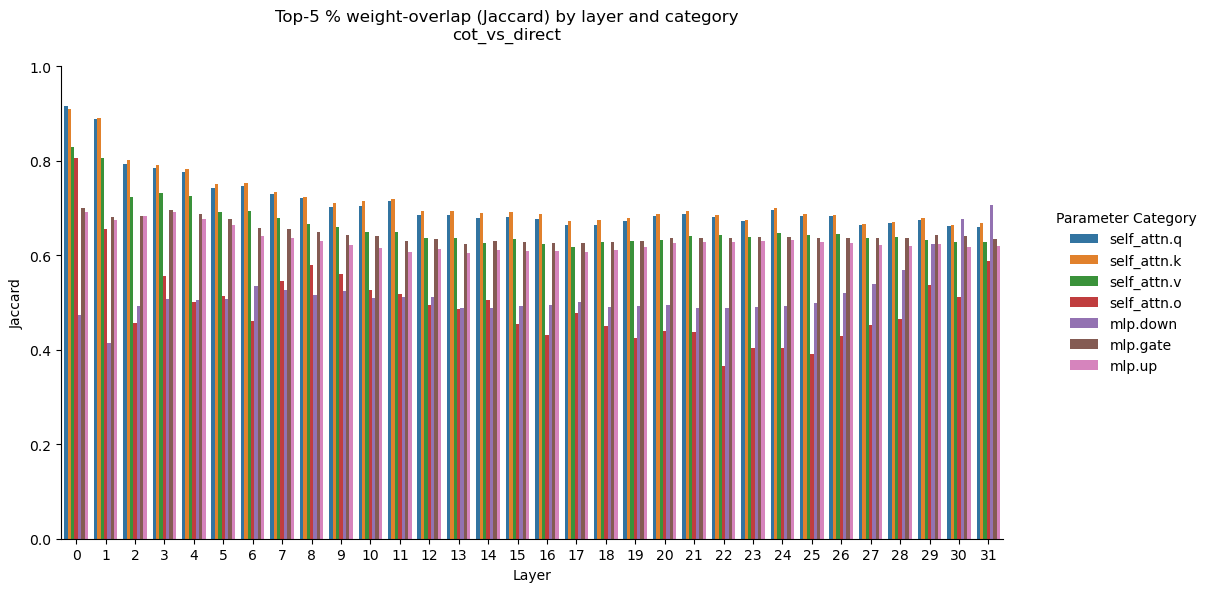

Creating plot for cot_vs_golden...
  Saved PNG: figures/jaccard_cot_vs_golden_20250811_161556.png
  Saved PDF: figures/jaccard_cot_vs_golden_20250811_161556.pdf


<Figure size 1200x600 with 0 Axes>

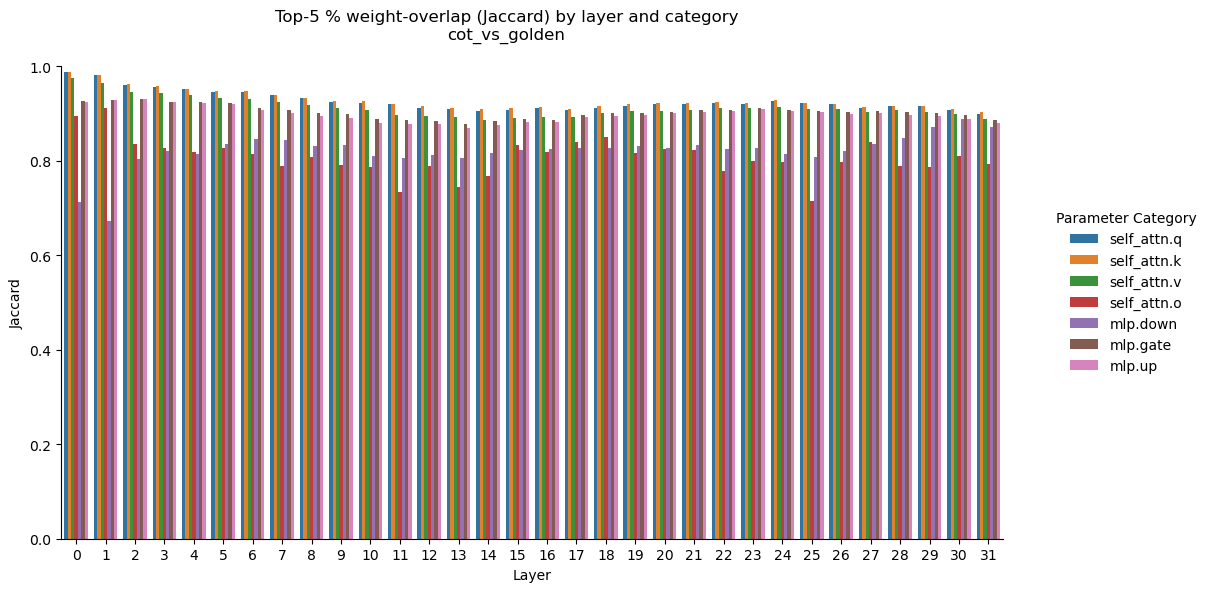

Creating plot for cot_vs_cot4shot...
  Saved PNG: figures/jaccard_cot_vs_cot4shot_20250811_161556.png
  Saved PDF: figures/jaccard_cot_vs_cot4shot_20250811_161556.pdf


<Figure size 1200x600 with 0 Axes>

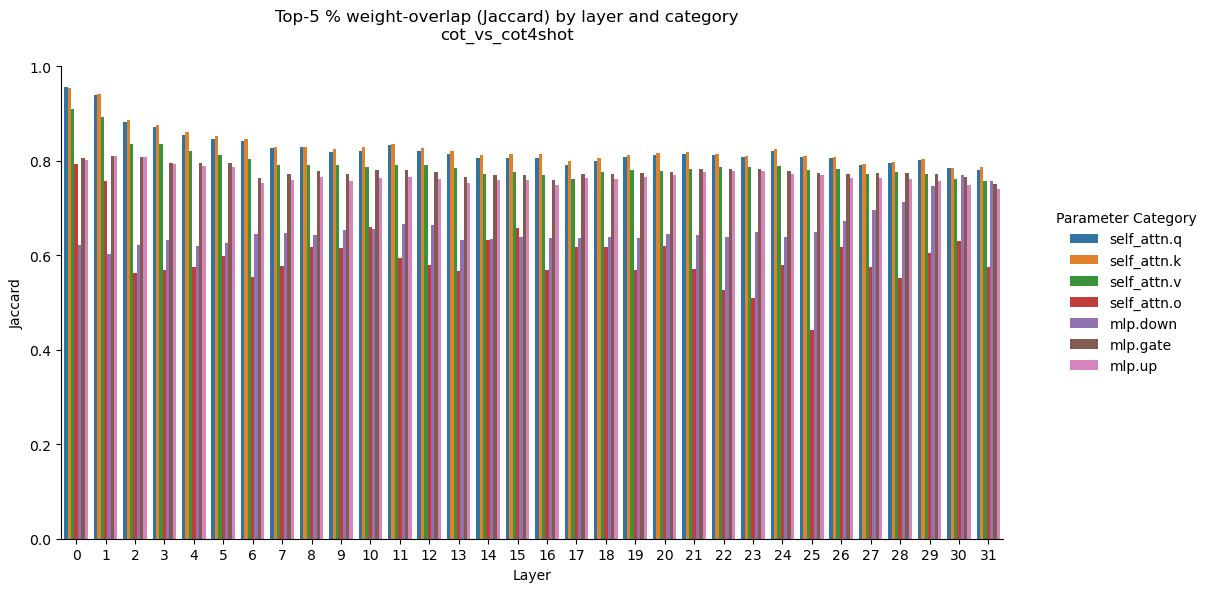

Creating plot for direct_vs_golden...
  Saved PNG: figures/jaccard_direct_vs_golden_20250811_161556.png
  Saved PDF: figures/jaccard_direct_vs_golden_20250811_161556.pdf


<Figure size 1200x600 with 0 Axes>

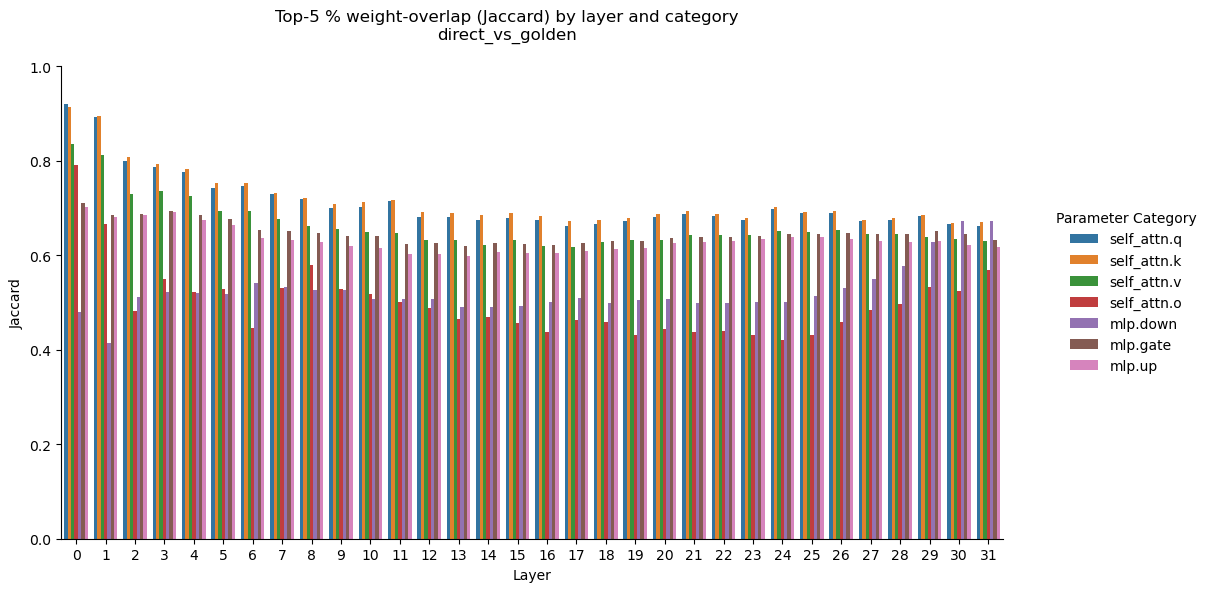

Creating plot for direct_vs_cot4shot...
  Saved PNG: figures/jaccard_direct_vs_cot4shot_20250811_161556.png
  Saved PDF: figures/jaccard_direct_vs_cot4shot_20250811_161556.pdf


<Figure size 1200x600 with 0 Axes>

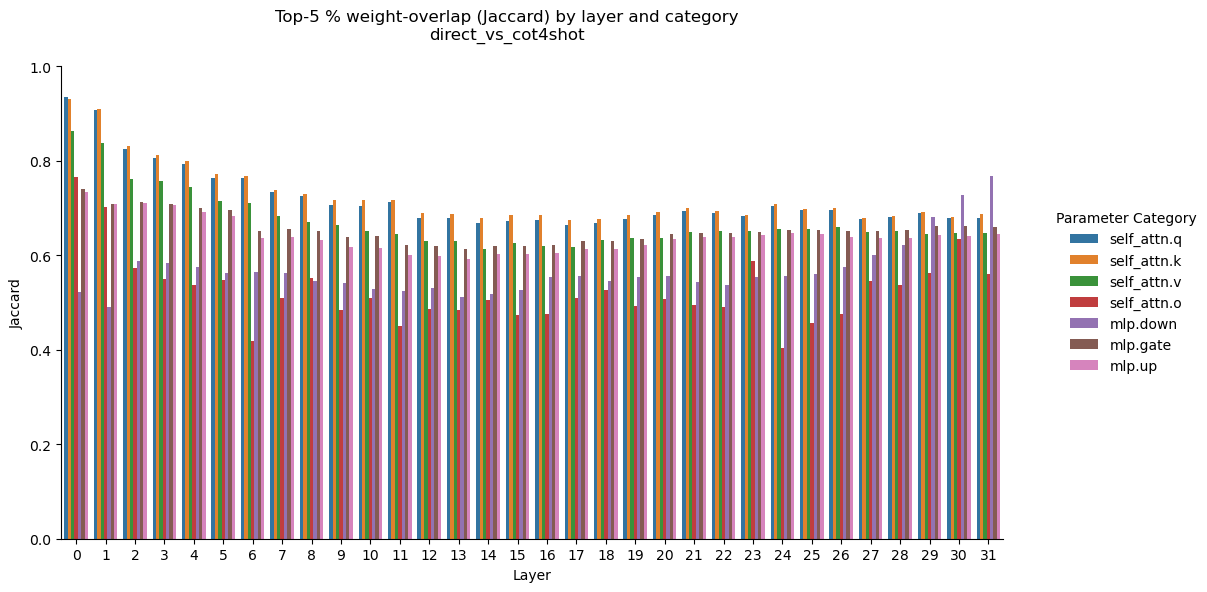

Creating plot for golden_vs_cot4shot...
  Saved PNG: figures/jaccard_golden_vs_cot4shot_20250811_161556.png
  Saved PDF: figures/jaccard_golden_vs_cot4shot_20250811_161556.pdf


<Figure size 1200x600 with 0 Axes>

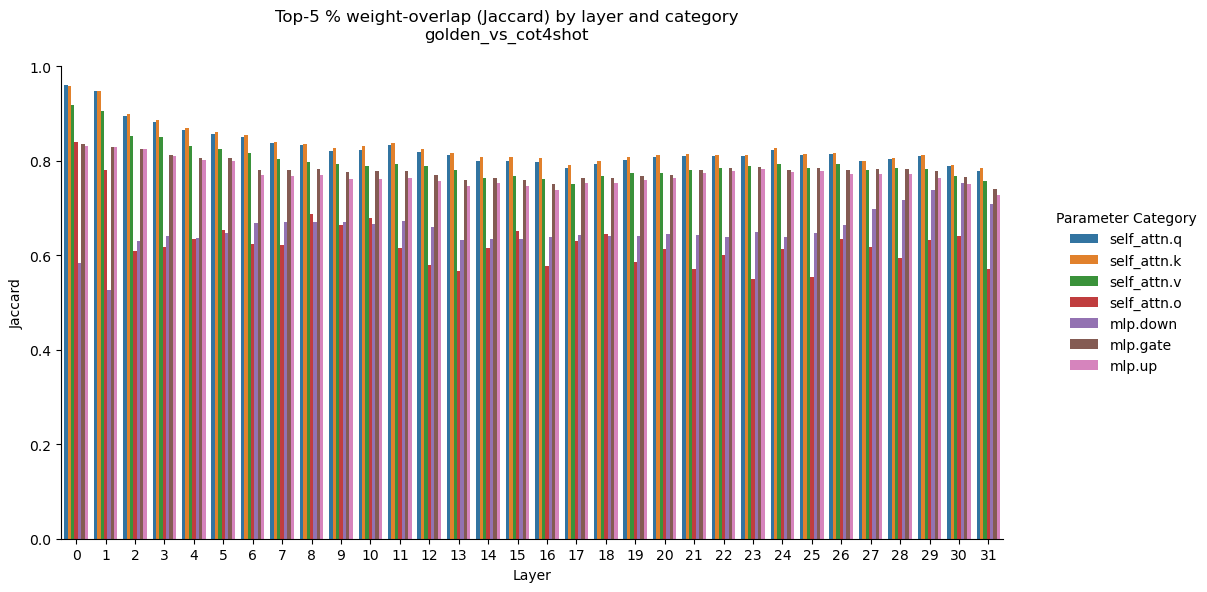

Creating combined visualization...
Saved Combined PNG: figures/jaccard_combined_20250811_161556.png
Saved Combined PDF: figures/jaccard_combined_20250811_161556.pdf
All plots created and saved in 25.12 seconds
Creating individual summary plots for each category...
Creating summary plot for self_attn.q...


/tmp/ipykernel_3403672/3959925145.py:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  cat_summary_plot = sns.barplot(


  Saved PNG: figures/jaccard_summary_self_attn_q_20250811_161556.png
  Saved PDF: figures/jaccard_summary_self_attn_q_20250811_161556.pdf


<Figure size 1800x500 with 0 Axes>

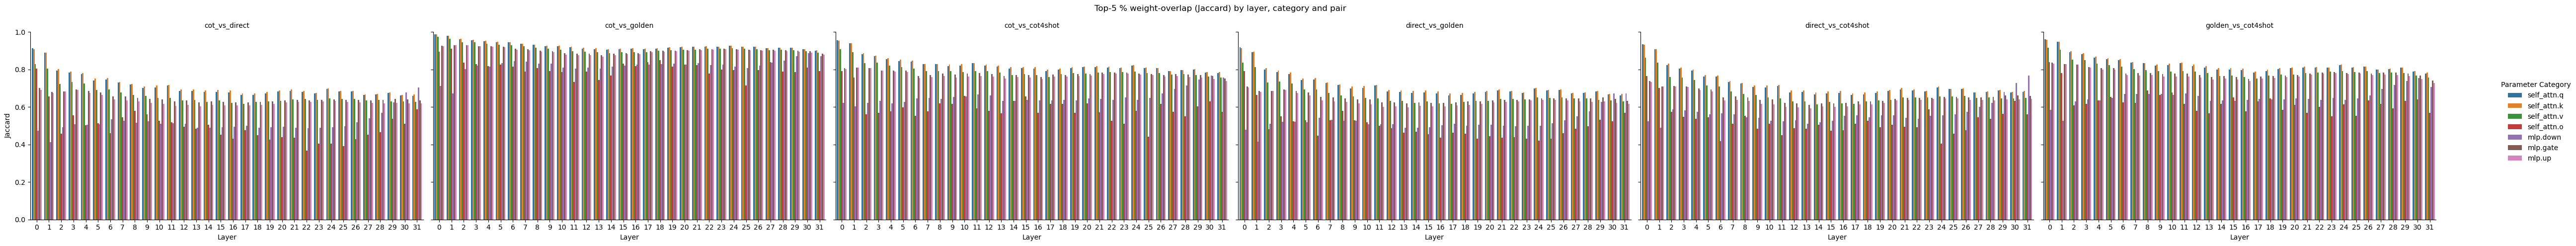

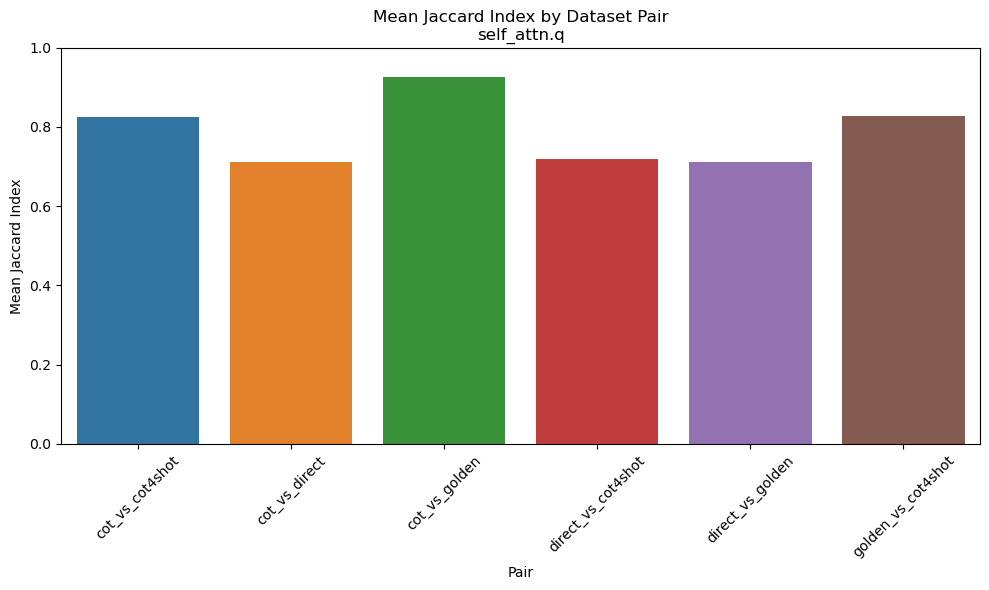

Creating summary plot for self_attn.k...


/tmp/ipykernel_3403672/3959925145.py:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  cat_summary_plot = sns.barplot(


  Saved PNG: figures/jaccard_summary_self_attn_k_20250811_161556.png
  Saved PDF: figures/jaccard_summary_self_attn_k_20250811_161556.pdf


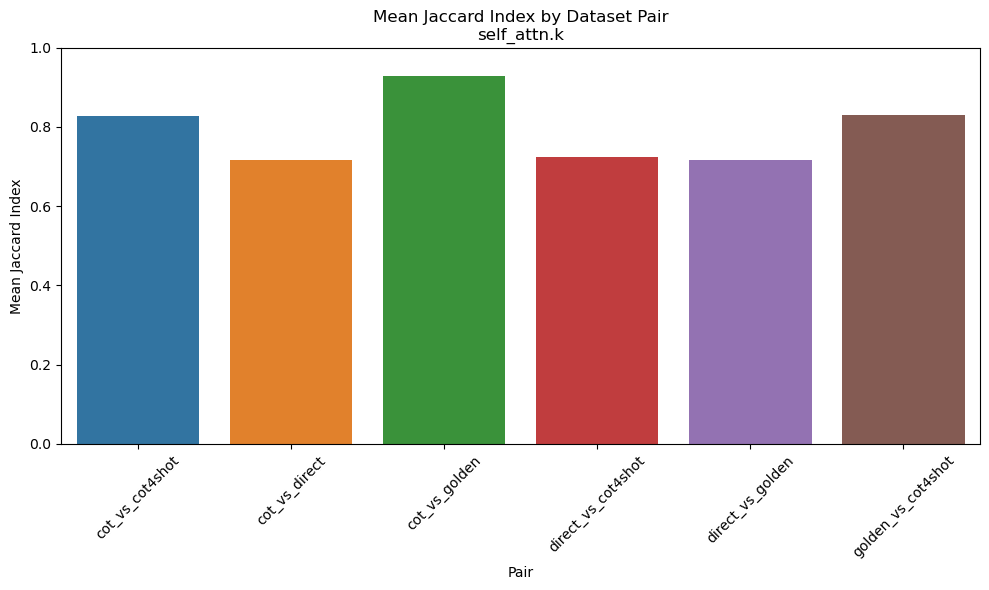

Creating summary plot for self_attn.v...


/tmp/ipykernel_3403672/3959925145.py:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  cat_summary_plot = sns.barplot(


  Saved PNG: figures/jaccard_summary_self_attn_v_20250811_161556.png
  Saved PDF: figures/jaccard_summary_self_attn_v_20250811_161556.pdf


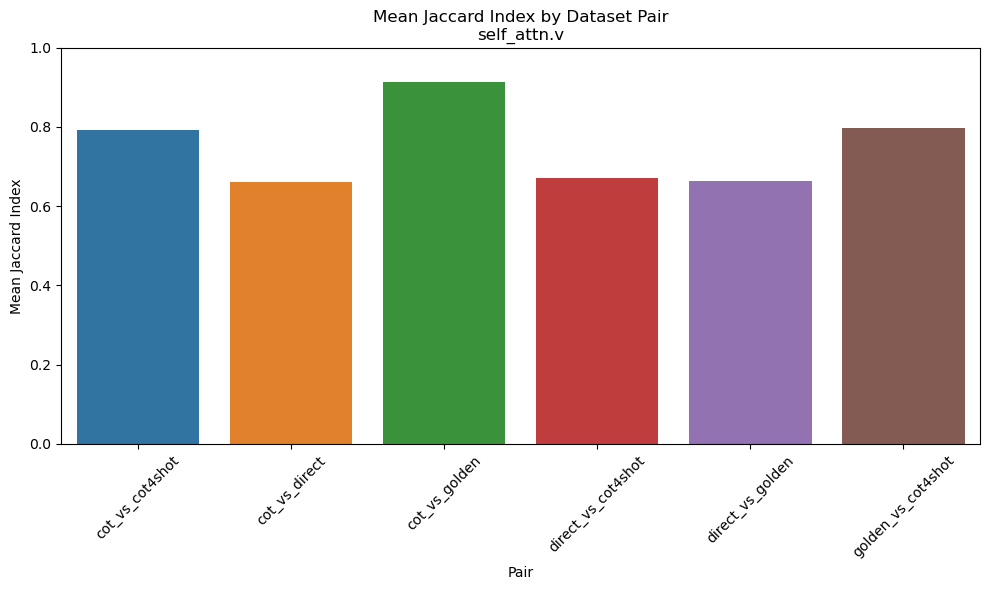

Creating summary plot for self_attn.o...


/tmp/ipykernel_3403672/3959925145.py:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  cat_summary_plot = sns.barplot(


  Saved PNG: figures/jaccard_summary_self_attn_o_20250811_161556.png
  Saved PDF: figures/jaccard_summary_self_attn_o_20250811_161556.pdf


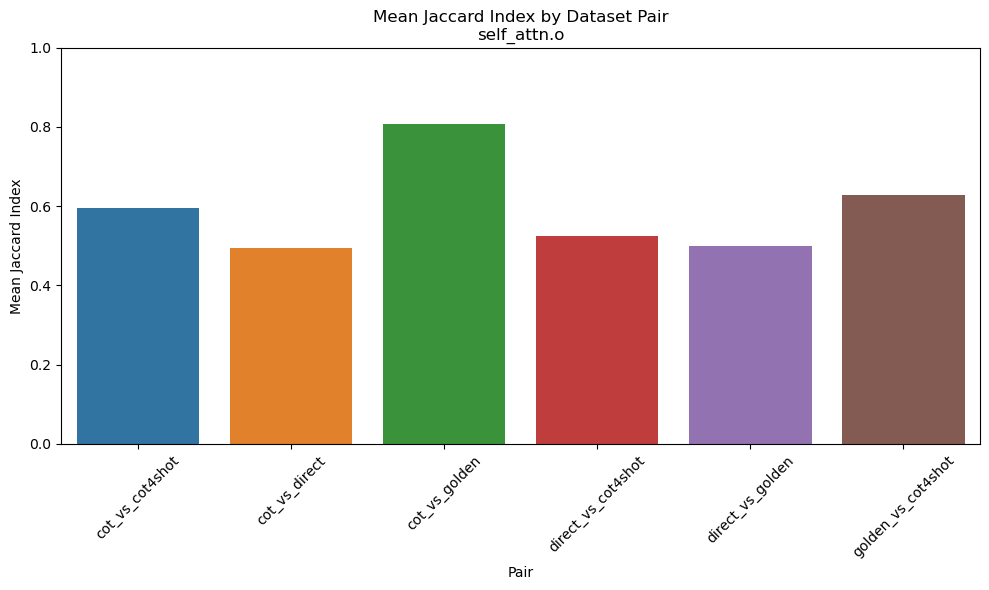

Creating summary plot for mlp.down...


/tmp/ipykernel_3403672/3959925145.py:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  cat_summary_plot = sns.barplot(


  Saved PNG: figures/jaccard_summary_mlp_down_20250811_161556.png
  Saved PDF: figures/jaccard_summary_mlp_down_20250811_161556.pdf


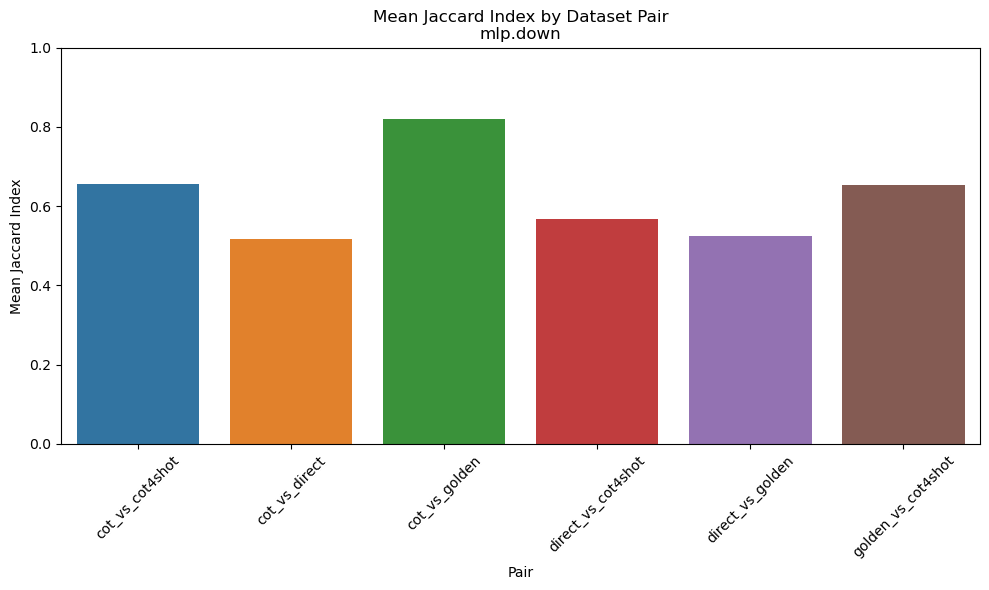

Creating summary plot for mlp.gate...


/tmp/ipykernel_3403672/3959925145.py:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  cat_summary_plot = sns.barplot(


  Saved PNG: figures/jaccard_summary_mlp_gate_20250811_161556.png
  Saved PDF: figures/jaccard_summary_mlp_gate_20250811_161556.pdf


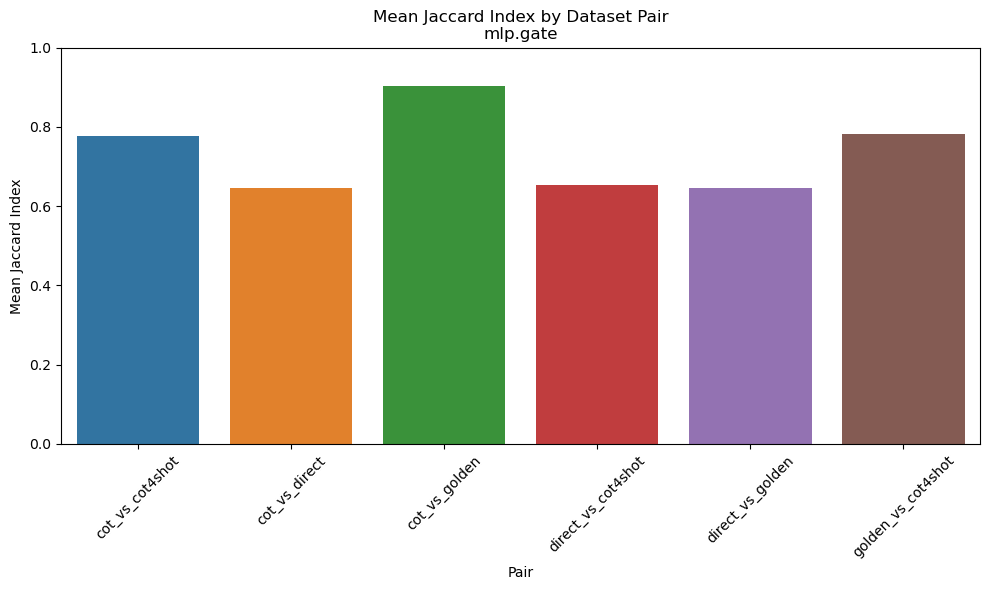

Creating summary plot for mlp.up...


/tmp/ipykernel_3403672/3959925145.py:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  cat_summary_plot = sns.barplot(


  Saved PNG: figures/jaccard_summary_mlp_up_20250811_161556.png
  Saved PDF: figures/jaccard_summary_mlp_up_20250811_161556.pdf


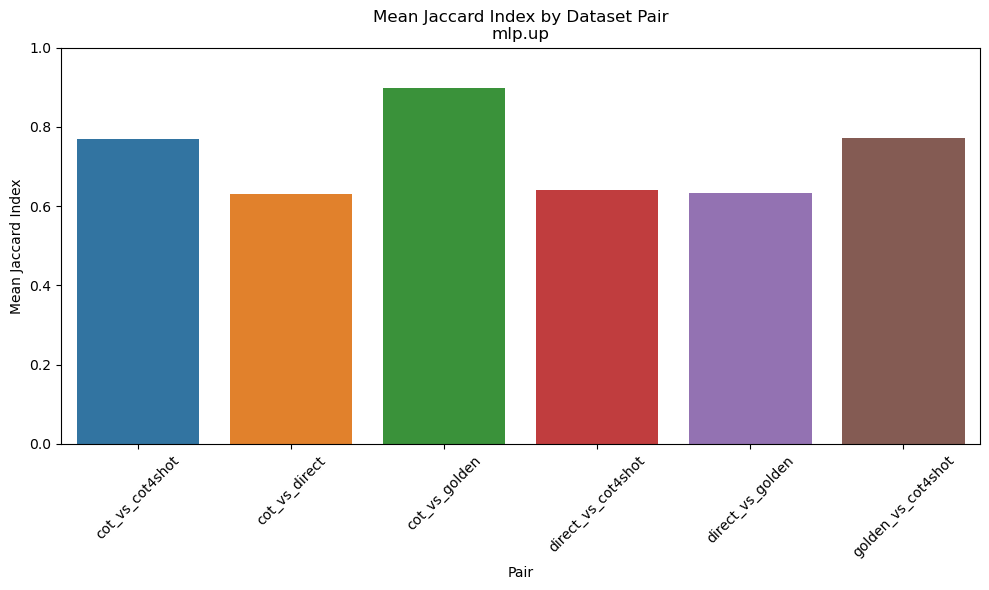

Creating overall summary plot...
Saved Overall Summary PNG: figures/jaccard_summary_overall_20250811_161556.png
Saved Overall Summary PDF: figures/jaccard_summary_overall_20250811_161556.pdf
All summary plots created and saved in 7.97 seconds

==== Mean Jaccard per category (averaged over layers) ====
              Pair    Category  Jaccard
   cot_vs_cot4shot    mlp.down 0.655149
   cot_vs_cot4shot    mlp.gate 0.777935
   cot_vs_cot4shot      mlp.up 0.768616
   cot_vs_cot4shot self_attn.k 0.828851
   cot_vs_cot4shot self_attn.o 0.596117
   cot_vs_cot4shot self_attn.q 0.824889
   cot_vs_cot4shot self_attn.v 0.793325
     cot_vs_direct    mlp.down 0.517671
     cot_vs_direct    mlp.gate 0.646100
     cot_vs_direct      mlp.up 0.631449
     cot_vs_direct self_attn.k 0.716029
     cot_vs_direct self_attn.o 0.494541
     cot_vs_direct self_attn.q 0.710439
     cot_vs_direct self_attn.v 0.661828
     cot_vs_golden    mlp.down 0.820437
     cot_vs_golden    mlp.gate 0.903126
     cot_vs_golde

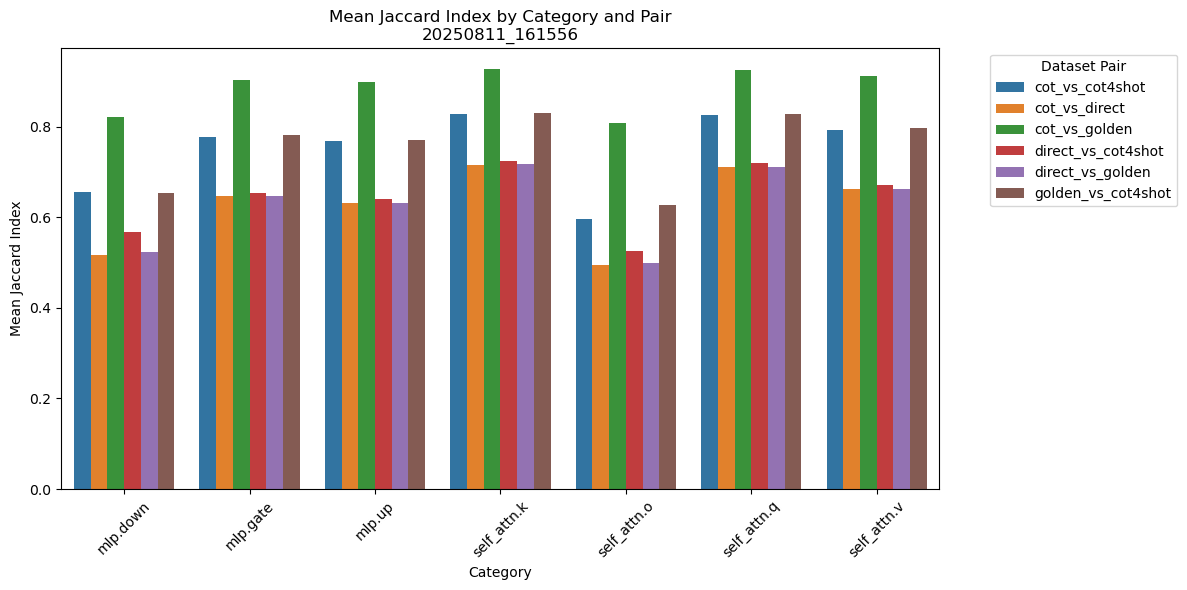

In [6]:

# -----------------------------------------------------------------------------
# Visualisation ────────────────────────────────────────────────────────────────
# -----------------------------------------------------------------------------
print("Creating individual visualizations for each pair...")
plot_start_time = time.time()

# Create output directory for figures
output_dir = "figures"
os.makedirs(output_dir, exist_ok=True)

# Create timestamp for filenames
timestamp = time.strftime("%Y%m%d_%H%M%S")

# Create individual plots for each pair
saved_plots = []
for pair_name in df['Pair'].unique():
    print(f"Creating plot for {pair_name}...")
    
    # Filter data for this pair
    pair_data = df[df['Pair'] == pair_name]
    
    # Create individual plot
    plt.figure(figsize=(12, 6))
    pair_plot = sns.catplot(
        data=pair_data,
        x="Layer",
        y="Jaccard",
        hue="Category",
        kind="bar",
        palette="tab10",
        height=6,
        aspect=1.5,
    )
    pair_plot.set_titles(f"{pair_name}")
    pair_plot.set(ylim=(0, 1))
    pair_plot.fig.subplots_adjust(top=0.9)
    pair_plot.fig.suptitle(f"Top‑5 % weight‑overlap (Jaccard) by layer and category\n{pair_name}")
    legend = pair_plot._legend
    legend.set_title("Parameter Category")
    legend.set_bbox_to_anchor((1.02, 0.5))
    legend.set_loc("center left")
    plt.tight_layout()
    
    # Save individual plot
    pair_filename = f"jaccard_{pair_name.replace('_vs_', '_vs_')}_{timestamp}"
    
    # Save as PNG
    png_path = os.path.join(output_dir, f"{pair_filename}.png")
    pair_plot.savefig(png_path, dpi=300, bbox_inches='tight')
    print(f"  Saved PNG: {png_path}")
    
    # Save as PDF
    pdf_path = os.path.join(output_dir, f"{pair_filename}.pdf")
    pair_plot.savefig(pdf_path, bbox_inches='tight')
    print(f"  Saved PDF: {pdf_path}")
    
    saved_plots.append(png_path)
    plt.show()

# Create combined plot (all pairs in one figure)
print("Creating combined visualization...")
plt.figure(figsize=(18, 5))
combined_plot = sns.catplot(
    data=df,
    x="Layer",
    y="Jaccard",
    hue="Category",
    col="Pair",
    kind="bar",
    palette="tab10",
    height=5,
    aspect=1.6,
)
combined_plot.set_titles("{col_name}")
combined_plot.set(ylim=(0, 1))
combined_plot.fig.subplots_adjust(top=0.85)
combined_plot.fig.suptitle("Top‑5 % weight‑overlap (Jaccard) by layer, category and pair")
legend = combined_plot._legend
legend.set_title("Parameter Category")
legend.set_bbox_to_anchor((1.02, 0.5))
legend.set_loc("center left")
plt.tight_layout()

# Save combined plot
combined_filename = f"jaccard_combined_{timestamp}"
combined_png_path = os.path.join(output_dir, f"{combined_filename}.png")
combined_plot.savefig(combined_png_path, dpi=300, bbox_inches='tight')
print(f"Saved Combined PNG: {combined_png_path}")

combined_pdf_path = os.path.join(output_dir, f"{combined_filename}.pdf")
combined_plot.savefig(combined_pdf_path, bbox_inches='tight')
print(f"Saved Combined PDF: {combined_pdf_path}")

plot_time = time.time() - plot_start_time
print(f"All plots created and saved in {plot_time:.2f} seconds")

# Create individual summary plots for each category
print("Creating individual summary plots for each category...")
summary_start_time = time.time()

# Get mean data
mean_data = df.groupby(['Pair', 'Category'])['Jaccard'].mean().reset_index()
saved_summary_plots = []

# Create individual plots for each category
for category in df['Category'].unique():
    print(f"Creating summary plot for {category}...")
    
    # Filter data for this category
    cat_data = mean_data[mean_data['Category'] == category]
    
    # Create individual summary plot
    plt.figure(figsize=(10, 6))
    cat_summary_plot = sns.barplot(
        data=cat_data,
        x='Pair',
        y='Jaccard',
        palette='tab10'
    )
    plt.title(f'Mean Jaccard Index by Dataset Pair\n{category}')
    plt.xticks(rotation=45)
    plt.ylabel('Mean Jaccard Index')
    plt.ylim(0, 1)
    plt.tight_layout()
    
    # Save individual summary plot
    cat_filename = f"jaccard_summary_{category.replace('.', '_')}_{timestamp}"
    
    # Save as PNG
    cat_png_path = os.path.join(output_dir, f"{cat_filename}.png")
    plt.savefig(cat_png_path, dpi=300, bbox_inches='tight')
    print(f"  Saved PNG: {cat_png_path}")
    
    # Save as PDF
    cat_pdf_path = os.path.join(output_dir, f"{cat_filename}.pdf")
    plt.savefig(cat_pdf_path, bbox_inches='tight')
    print(f"  Saved PDF: {cat_pdf_path}")
    
    saved_summary_plots.append(cat_png_path)
    plt.show()

# Create overall summary plot (all categories in one figure)
print("Creating overall summary plot...")
plt.figure(figsize=(12, 6))
overall_summary_plot = sns.barplot(
    data=mean_data,
    x='Category',
    y='Jaccard',
    hue='Pair',
    palette='tab10'
)
plt.title(f'Mean Jaccard Index by Category and Pair\n{timestamp}')
plt.xticks(rotation=45)
plt.ylabel('Mean Jaccard Index')
plt.legend(title='Dataset Pair', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Save overall summary plot
overall_summary_filename = f"jaccard_summary_overall_{timestamp}"
overall_summary_png_path = os.path.join(output_dir, f"{overall_summary_filename}.png")
plt.savefig(overall_summary_png_path, dpi=300, bbox_inches='tight')
print(f"Saved Overall Summary PNG: {overall_summary_png_path}")

overall_summary_pdf_path = os.path.join(output_dir, f"{overall_summary_filename}.pdf")
plt.savefig(overall_summary_pdf_path, bbox_inches='tight')
print(f"Saved Overall Summary PDF: {overall_summary_pdf_path}")

summary_time = time.time() - summary_start_time
print(f"All summary plots created and saved in {summary_time:.2f} seconds")

# -----------------------------------------------------------------------------
# Statistics ─────────────────────────────────────────────────────────────────--
# -----------------------------------------------------------------------------
print("\n==== Mean Jaccard per category (averaged over layers) ====")
mean_table = (
    df.groupby(["Pair", "Category"], as_index=False)["Jaccard"]
    .mean()
    .sort_values(["Pair", "Category"])
)
print(mean_table.to_string(index=False))

# total average
total_mean = df["Jaccard"].mean()
print(f"\n==== Overall mean Jaccard index: {total_mean:.4f} ====")

# -----------------------------------------------------------------------------
# Timing Summary ───────────────────────────────────────────────────────────────
# -----------------------------------------------------------------------------
print(f"\n==== TIMING SUMMARY ====")
print(f"Total computation time: {total_time:.2f} seconds")
print(f"DataFrame creation: {df_time:.2f} seconds")
print(f"Main plot creation: {plot_time:.2f} seconds")
print(f"Summary plot creation: {summary_time:.2f} seconds")
print(f"Total execution time: {time.time() - start_time:.2f} seconds")
print(f"Number of pairs processed: {len(pairs)}")
print(f"DataFrame shape: {df.shape}")
print(f"\n==== FILES SAVED ====")
print(f"Individual pair plots: {len(saved_plots)} files")
for plot in saved_plots:
    print(f"  - {plot}")
print(f"Combined plot: {combined_png_path}")
print(f"Individual category summary plots: {len(saved_summary_plots)} files")
for plot in saved_summary_plots:
    print(f"  - {plot}")
print(f"Overall summary plot: {overall_summary_png_path}")
print(f"Data: {csv_path}")


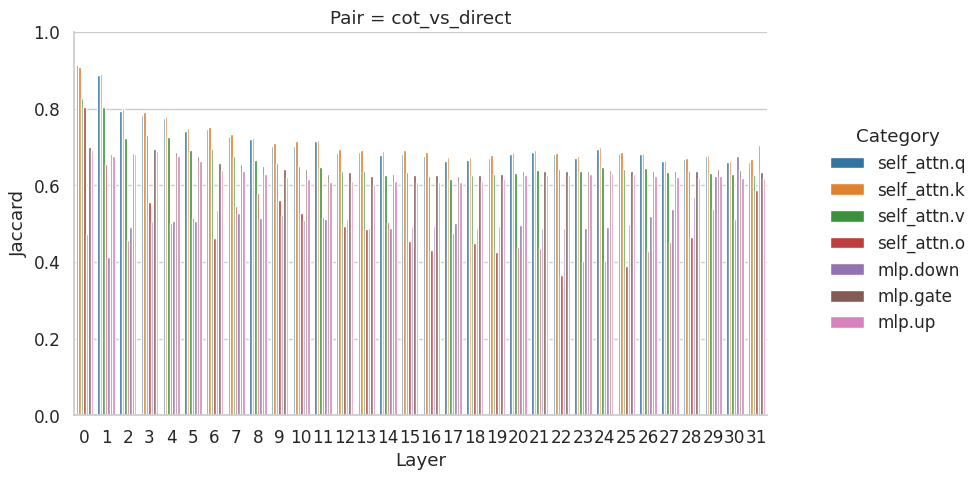

In [7]:
sns.set(style="whitegrid", font_scale=1.1)
g = sns.catplot(
    data=df,
    kind="bar",
    x="Layer",
    y="Jaccard",
    hue="Category",
    col="Pair",
    palette="tab10",
    height=5,
    aspect=1.3,
    sharey=True,
)

g.set(ylim=(0, 1))
# Make room at right & move legend outside
g.fig.subplots_adjust(right=0.83)  # leave ~17 % for legend
new_legend = g._legend
new_legend.set_bbox_to_anchor((1.02, 0.5))
new_legend.set_loc("center left")
new_legend.set_title("Category")

plt.tight_layout()
plt.show()


In [4]:
df

,Pair,Layer,Category,Jaccard
0,cot_vs_direct,30,self_attn.o,0.510769
1,cot_vs_direct,21,self_attn.q,0.686328
2,cot_vs_direct,25,self_attn.q,0.683844
3,cot_vs_direct,16,mlp.up,0.608058
4,cot_vs_direct,1,mlp.gate,0.680832
...,...,...,...,...
219,cot_vs_direct,8,mlp.gate,0.649058
220,cot_vs_direct,18,mlp.gate,0.627591
221,cot_vs_direct,25,mlp.down,0.498596
222,cot_vs_direct,17,self_attn.q,0.663189


In [ ]:

# 给出layer平均值关于不同category的jaccard index
mean_jaccard = df.groupby("Category")["Jaccard"].mean().reset_index
print(mean_jaccard)